# Random Forest (Ensemble) — Income Classification

An ensemble that averages 150 de-correlated decision trees. The model is trained on the UCI Adult dataset using the shared `data_prep` module, evaluated with six metrics, and saved to `saved_models/` alongside its metrics in `metrics/`.

In [1]:
import json
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, matthews_corrcoef,
                             confusion_matrix, classification_report)

import data_prep as dp

# Same stratified split for every model (also refreshes ../test_data.csv)
X_train, X_test, y_train, y_test = dp.get_splits()
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (26048, 14) | Test: (6513, 14)


## Train the model

In [2]:
# Build and train the pipeline: preprocessing -> Random Forest (Ensemble)
pipeline = Pipeline([
    ("prep", dp.build_preprocessor()),
    ("model", RandomForestClassifier(n_estimators=150, max_depth=18, min_samples_leaf=2, random_state=dp.RANDOM_SEED, n_jobs=-1)),
])
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
print("Trained Random Forest (Ensemble).")


Trained Random Forest (Ensemble).


## Evaluation metrics

In [3]:
# Compute the six evaluation metrics
metrics = {
    "Model": "Random Forest (Ensemble)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_proba),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "MCC": matthews_corrcoef(y_test, y_pred),
}
for key, value in metrics.items():
    print(f"{key:10s}: {value}")


Model     : Random Forest (Ensemble)
Accuracy  : 0.8671886995240289
AUC       : 0.920335553331545
Precision : 0.7966244725738396
Recall    : 0.6020408163265306
F1        : 0.6857973120232473
MCC       : 0.6131676985501288


## Confusion matrix & classification report

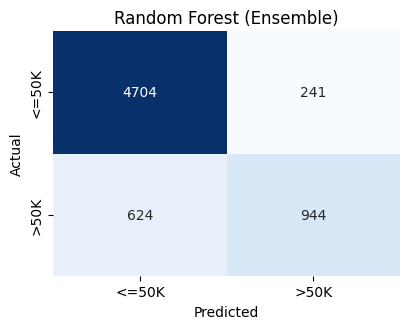

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.92      4945
        >50K       0.80      0.60      0.69      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.78      0.80      6513
weighted avg       0.86      0.87      0.86      6513



In [4]:
# Confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.2, 3.4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Random Forest (Ensemble)")
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"],
                            zero_division=0))


## Save the pipeline and metrics

In [5]:
# Persist the trained pipeline and its metrics
dp.SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
dp.METRICS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline, dp.SAVED_MODELS_DIR / "random_forest.pkl", compress=3)
with open(dp.METRICS_DIR / "random_forest_metrics.json", "w") as fh:
    json.dump(metrics, fh, indent=2)

print("Saved saved_models/random_forest.pkl and metrics/random_forest_metrics.json")


Saved saved_models/random_forest.pkl and metrics/random_forest_metrics.json
